<a href="https://colab.research.google.com/github/Aneesha-Shr/Fiber-Image-Tracking/blob/main/Image_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Total images: 50000
Blurry images: 13
Not blurry images: 49987
Percentage of blurry images: 0.03%


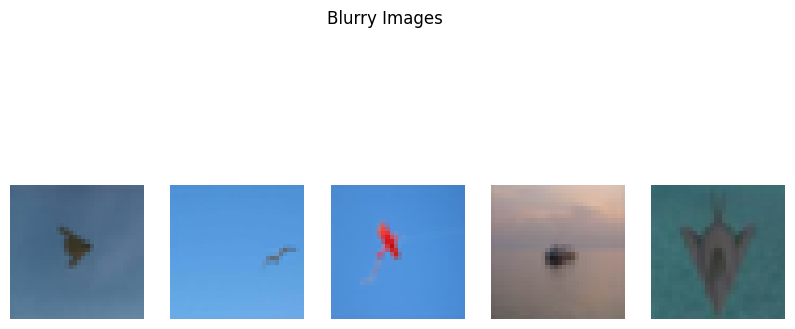

In [2]:
#Laplacian Method Practice

import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
def is_blurry(image, threshold=100.0):
    # Convert the image to grayscale
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Compute the Laplacian of the image and then the variance
    laplacian_var = cv2.Laplacian(gray_image, cv2.CV_64F).var()

    return laplacian_var < threshold, laplacian_var

# Initialize lists to store images
blurry_images = []
not_blurry_images = []

# Analyze the dataset
for i in range(x_train.shape[0]):
    # Convert the image from RGB to BGR (OpenCV uses BGR format)
    image = cv2.cvtColor(x_train[i], cv2.COLOR_RGB2BGR)

    # Check if the image is blurry
    is_blur, _ = is_blurry(image)

    if is_blur:
        blurry_images.append(image)
    else:
        not_blurry_images.append(image)


# Output the results
total_images = x_train.shape[0]
blurry_count = len(blurry_images)
not_blurry_count = len(not_blurry_images)

print(f"Total images: {total_images}")
print(f"Blurry images: {blurry_count}")
print(f"Not blurry images: {not_blurry_count}")
print(f"Percentage of blurry images: {blurry_count / total_images * 100:.2f}%")

# Plot a few blurry and not blurry images to compare
def plot_images(images, title, num_images=5):
    plt.figure(figsize=(10, 5))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

# Plot blurry images
if blurry_images:
    plot_images(blurry_images, 'Blurry Images', min(5, len(blurry_images)))


In [3]:
!ls
!git clone https://github.com/Aneesha-Shr/Fiber-Image-Tracking

sample_data
Cloning into 'Fiber-Image-Tracking'...
remote: Enumerating objects: 267, done.
remote: Counting objects: 100% (267/267), done.
remote: Compressing objects: 100% (254/254), done.
remote: Total 267 (delta 39), reused 38 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (267/267), 65.35 MiB | 19.17 MiB/s, done.
Resolving deltas: 100% (39/39), done.


In [7]:
import os
from PIL import Image
import numpy as np
import cv2
import matplotlib.pylab as plt

plt.style.use('ggplot')

def sharpen_images(local_folder_path, output_folder):
  # Loop over all tendon images and SHARPEN
  #local_folder_path = 'Fiber-Image-Tracking/IO Fiber Tracking/Intermediate Folder'

  # Create an output folder for the sharpened images to keep things organized
  #output_folder = 'Sharpened_Images'
  os.makedirs(output_folder, exist_ok=True)

  if not os.path.isdir(local_folder_path):
      print(f"Error: Folder not found at '{local_folder_path}'")
  else:
      print(f"Searching for images in: {local_folder_path}")

      # Define acceptable image extensions
      image_extensions = ('.png', '.jpg', '.jpeg')

      for i, filename in enumerate(os.listdir(local_folder_path)):

          # path to the file
          full_file_path = os.path.join(local_folder_path, filename)

          # Filter to ensure we only process actual image files
          if os.path.isfile(full_file_path) and filename.lower().endswith(image_extensions):

              print(f"Processing image {i+1}: {filename}")

              # Read the image into a NumPy array using OpenCV
              tendon_img = cv2.imread(full_file_path)

              # Check if image was read successfully (e.g., not a corrupted file)
              if tendon_img is None:
                  print(f"Warning: Could not read image file {filename}. Skipping.")
                  continue

              # Sharpening Kernel (this is correct)
              kernel_sharpening = np.array([[-1,-1,-1],
                                            [-1,9,-1],
                                            [-1,-1,-1]])

              # 4. FIX: Apply the filter to the actual image data (tendon_img)
              sharpened = cv2.filter2D(tendon_img, -1, kernel_sharpening)

              # Display the sharpened image (one time is enough)
              fig, ax = plt.subplots(1, 2, figsize=(15, 7))

              # Plot the original image for comparison
              ax[0].imshow(cv2.cvtColor(tendon_img, cv2.COLOR_BGR2RGB))
              ax[0].axis('off')
              ax[0].set_title(f'Original: {filename}')

              # Plot the sharpened image
              ax[1].imshow(cv2.cvtColor(sharpened, cv2.COLOR_BGR2RGB))
              ax[1].axis('off')
              ax[1].set_title('Sharpened Image')

              plt.tight_layout()
              plt.show()

              # Save the sharpened image
              output_path = os.path.join(output_folder, f"sharpened_{filename}")
              cv2.imwrite(output_path, sharpened)
              print(f"Saved sharpened image to: {output_path}")

          elif not filename.startswith('.'): # Skip hidden files, but print a message for others
              print(f"Skipping non-image file: {filename}")

In [6]:
!ls

Fiber-Image-Tracking  sample_data
